In [ ]:
# plot the PA change of a target

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord
from astroplan import Observer, FixedTarget
from astroplan.plots import plot_parallactic
from datetime import datetime
from zoneinfo import ZoneInfo

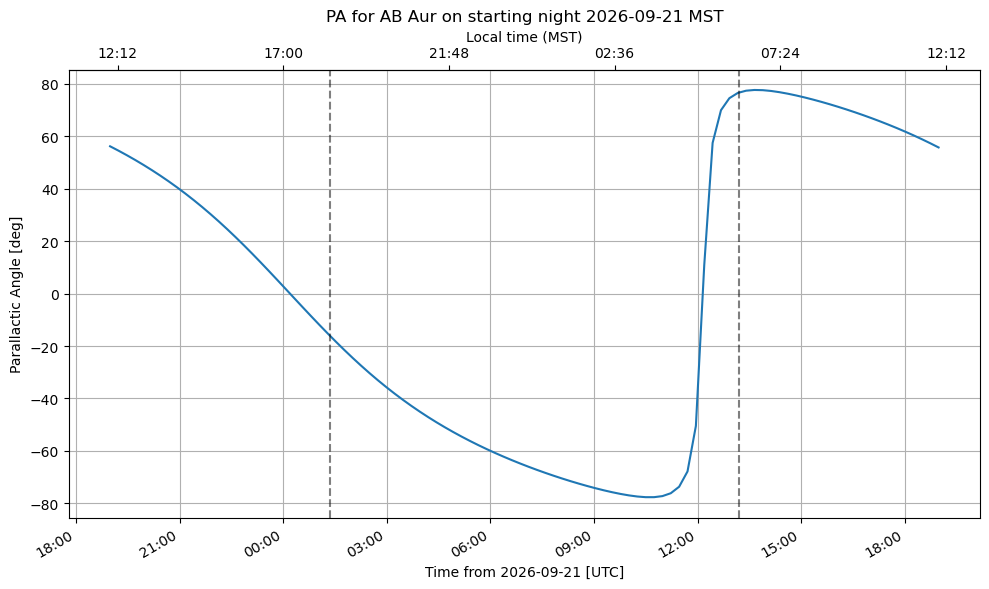

In [19]:
# 1. Define your location (e.g., Zurich) and your target (e.g., Orion Nebula)

lat_mgio = 32.7016*u.deg
lon_mgio = -109.8719*u.deg
el_mgio = 3220.8*u.m
target_name = "AB Aur"
tucson_tz = ZoneInfo("America/Phoenix")

observer = Observer(latitude=lat_mgio, longitude=lon_mgio, elevation=el_mgio, name="MGIO")
coordinates = SkyCoord.from_name(target_name)
target = FixedTarget(coord=coordinates, name=target_name)

# define epoch
midnight_time = Time(
    datetime(2026, 9, 21, 23, 59, 0, tzinfo=tucson_tz)
)

local = midnight_time.to_datetime(timezone=tucson_tz)


# 3. Create the plot over a 24-hour window centered around midnight
from matplotlib import dates as mdates

fig, ax = plt.subplots(figsize=(10, 6))
plot_parallactic(target, observer, midnight_time, ax=ax)

sunset_20260921 = Time(
    datetime(2026, 9, 21, 18, 21, 0, tzinfo=tucson_tz)
)
sunrise_20260921 = Time(
    datetime(2026, 9, 22, 6, 12, 0, tzinfo=tucson_tz)
)

# plot_parallactic uses radians; convert to degrees
for line in ax.get_lines():
    line.set_ydata(np.degrees(line.get_ydata()))
ax.relim()
ax.autoscale_view(scalex=False)
ax.set_ylabel("Parallactic Angle [deg]")

# Top axis: same UTC data coords, labeled in Phoenix local time
ax_local = ax.secondary_xaxis("top")
ax_local.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=tucson_tz))
ax_local.set_xlabel(f"Local time ({local:%Z})")

ax.axvline(sunset_20260921.datetime.replace(tzinfo=None), color='k', linestyle='--', alpha=0.5)
ax.axvline(sunrise_20260921.datetime.replace(tzinfo=None), color='k', linestyle='--', alpha=0.5)
ax.set_title(f"PA for {target.name} on starting night {local:%Y-%m-%d %Z}")
ax.grid(True)
plt.tight_layout()
plt.show()
